# Product Clustering using K-Means

## Tujuan

Notebook ini bertujuan untuk mengelompokkan produk berdasarkan karakteristik numeriknya menggunakan algoritma **K-Means Clustering**.

Hasil clustering diharapkan dapat membantu mengidentifikasi kelompok produk yang memiliki karakteristik serupa sehingga mempermudah proses segmentasi produk berdasarkan popularitas dan karakteristik penjual.

Variabel yang digunakan meliputi:

- Average Price
- Rating
- Review Count
- Sold
- Seller Followers
- Seller Rating

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv("../data/processed/ecommerce.csv")

df.head()

,keyword,product_id,product_name,url,currency,original_price_min,original_price_max,final_price_min,final_price_max,discount_percent,...,seller_name,seller_rating,seller_followers,seller_product,seller_response_rate,seller_response_time,seller_joined,price_avg,price_range,seller_age
0,headset,42531428335,VIVAN Earphone Headphone Headset In-Ear 3D Sub...,https://shopee.co.id/VIVAN-Earphone-Headphone-...,IDR,107000.0,107000.0,107000.0,107000.0,0,...,Vivan Official Shop,596400.0,716700.0,477.0,100.0,1,10 years ago,107000.0,0.0,10
1,headset,25117212844,Lenovo Thinkplus TH30 Headset Bluetooth V5.3 W...,https://shopee.co.id/Lenovo-Thinkplus-TH30-Hea...,IDR,240000.0,480000.0,142000.0,289000.0,53,...,Thinkplus Audio Store,56800.0,31400.0,235.0,100.0,2,33 months ago,215500.0,147000.0,33
2,headset,826361914,Xiaomi In-Ear Headphones Basic | Built-in Micr...,https://shopee.co.id/Xiaomi-In-Ear-Headphones-...,IDR,119000.0,119000.0,99000.0,99000.0,17,...,Xiaomi Official Store,3200000.0,3400000.0,341.0,95.0,2,8 years ago,99000.0,0.0,8
3,headset,40651424918,Pods Air Headset EarPods Kabel Earphone Handsf...,https://shopee.co.id/Pods-Air-Headset-EarPods-...,IDR,185165.0,185165.0,185165.0,185165.0,0,...,Pods Air,4100.0,3100.0,12.0,79.0,2,18 months ago,185165.0,0.0,18
4,headset,43662379094,Baseus Bass BH1 Lite Wireless Headphone Super ...,https://shopee.co.id/Baseus-Bass-BH1-Lite-Wire...,IDR,371420.0,371420.0,371420.0,371420.0,0,...,Baseus Official Shop,379900.0,249800.0,262.0,100.0,1,6 years ago,371420.0,0.0,6


## Feature Selection

Tahap pertama adalah memilih variabel numerik yang akan digunakan dalam proses clustering.

Variabel yang dipilih meliputi:

- Average Price
- Rating
- Review Count
- Sold
- Seller Followers
- Seller Rating

In [84]:
features = [
    "price_avg",
    "rating",
    "review_count",
    "sold",
    "seller_followers",
    "seller_rating"
]

X = df[features].fillna(0)

X.head()

,price_avg,rating,review_count,sold,seller_followers,seller_rating
0,107000.0,4.9,13.0,68.0,716700.0,596400.0
1,215500.0,4.9,10300.0,10000.0,31400.0,56800.0
2,99000.0,4.9,63400.0,10000.0,3400000.0,3200000.0
3,185165.0,5.0,29.0,6000.0,3100.0,4100.0
4,371420.0,4.9,750.0,2000.0,249800.0,379900.0


## Feature Scaling

Karena setiap variabel memiliki satuan yang berbeda, dilakukan standardisasi menggunakan **StandardScaler**.

Proses ini bertujuan agar seluruh fitur memiliki skala yang sebanding sehingga tidak ada variabel yang mendominasi proses clustering.

In [85]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Menentukan Jumlah Cluster

Jumlah cluster ditentukan menggunakan **Elbow Method**.

Metode ini menghitung nilai inertia untuk beberapa jumlah cluster. Titik siku (elbow) digunakan sebagai acuan dalam menentukan jumlah cluster yang paling optimal.

In [86]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

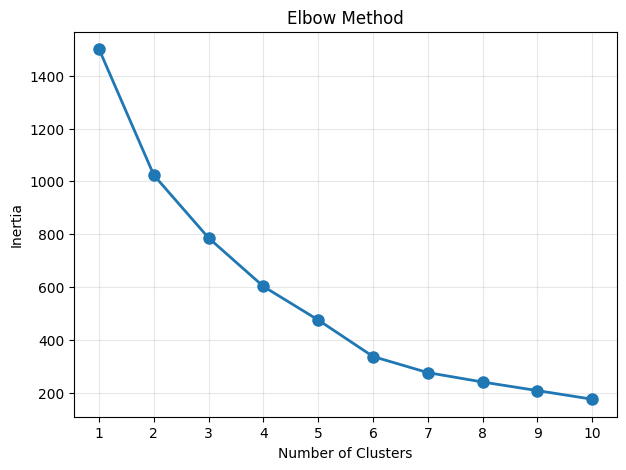

In [87]:
plt.figure(figsize=(7,5))

plt.plot(
    K,
    inertia,
    marker="o",
    linewidth=2,
    markersize=8
)

plt.xticks(K)

plt.grid(alpha=0.3)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

## Training K-Means

Berdasarkan hasil Elbow Method dipilih **3 cluster** sebagai jumlah cluster terbaik.

Model K-Means kemudian dilatih menggunakan data yang telah distandardisasi.

In [88]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

## Cluster Distribution

Visualisasi berikut menunjukkan jumlah produk pada setiap cluster yang berhasil dibentuk oleh algoritma K-Means.

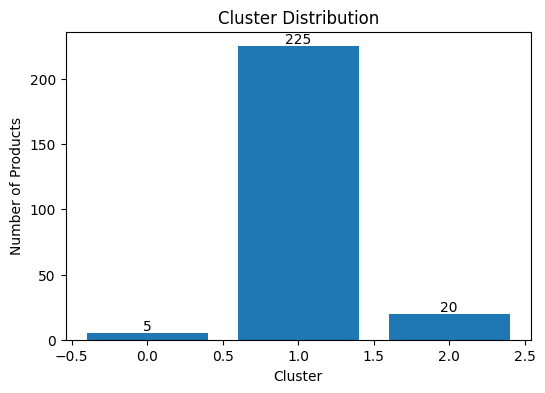

In [89]:
cluster_count = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))

bars = plt.bar(
    cluster_count.index,
    cluster_count.values
)

plt.title("Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Products")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+2,
        int(bar.get_height()),
        ha="center"
    )

plt.show()

## PCA Visualization

Karena data memiliki banyak dimensi, digunakan **Principal Component Analysis (PCA)** untuk mereduksi dimensi menjadi dua komponen utama sehingga hasil clustering dapat divisualisasikan.

In [90]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

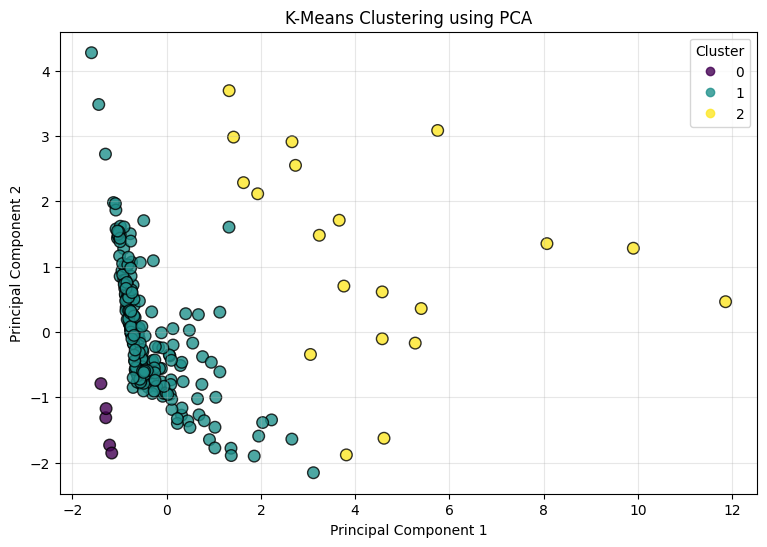

In [91]:
plt.figure(figsize=(9,6))

scatter = plt.scatter(

    df["PCA1"],

    df["PCA2"],

    c=df["cluster"],

    s=70,

    edgecolors="black",

    alpha=0.8

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering using PCA")

plt.grid(alpha=0.3)

plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.show()

## Cluster Center

Cluster center menunjukkan nilai rata-rata setiap variabel pada masing-masing cluster setelah dikembalikan ke skala aslinya menggunakan inverse transform.

Informasi ini digunakan untuk mengidentifikasi karakteristik utama dari setiap cluster.

In [92]:
cluster_center = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(2)

cluster_center.index.name = "Cluster"

cluster_center.columns = [
    "Average Price",
    "Rating",
    "Review Count",
    "Sold",
    "Seller Followers",
    "Seller Rating"
]

In [93]:
cluster_center["Average Price"] = cluster_center["Average Price"].map(
    lambda x: f"Rp {x:,.0f}"
)

cluster_center["Review Count"] = cluster_center["Review Count"].map(
    lambda x: f"{x:,.0f}"
)

cluster_center["Sold"] = cluster_center["Sold"].map(
    lambda x: f"{x:,.0f}"
)

cluster_center["Seller Followers"] = cluster_center["Seller Followers"].map(
    lambda x: f"{x:,.0f}"
)

In [94]:
cluster_center.insert(
    0,
    "Category",
    [
        "Low Popularity",
        "Medium Popularity",
        "High Popularity"
    ]
)

cluster_center

,Category,Average Price,Rating,Review Count,Sold,Seller Followers,Seller Rating
Cluster,,,,,,,
0,Low Popularity,"Rp 5,687,600",-0.00,0,2,"10,989",2344.80
1,Medium Popularity,"Rp 4,149,897",4.88,806,"1,429","74,686",73427.13
2,High Popularity,"Rp 4,436,150",4.93,"12,811","6,052","2,506,935",1440270.00


## Cluster Summary

Tahapan berikut digunakan untuk melihat karakteristik masing-masing cluster berdasarkan nilai rata-rata setiap fitur.

In [95]:
cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_summary["price_avg"] = cluster_summary["price_avg"].map(
    lambda x: f"Rp {x:,.0f}"
)

cluster_summary["review_count"] = cluster_summary["review_count"].map(
    lambda x: f"{x:,.0f}"
)

cluster_summary["sold"] = cluster_summary["sold"].map(
    lambda x: f"{x:,.0f}"
)

cluster_summary["seller_followers"] = cluster_summary["seller_followers"].map(
    lambda x: f"{x:,.0f}"
)

cluster_summary

,price_avg,rating,review_count,sold,seller_followers,seller_rating
cluster,,,,,,
0,"Rp 5,687,600",NaN,0,2,"10,989",2344.80
1,"Rp 4,149,897",4.88,806,"1,429","74,686",73427.13
2,"Rp 4,436,150",4.93,"12,811","6,052","2,506,935",1440270.00


## Visualisasi Karakteristik Cluster

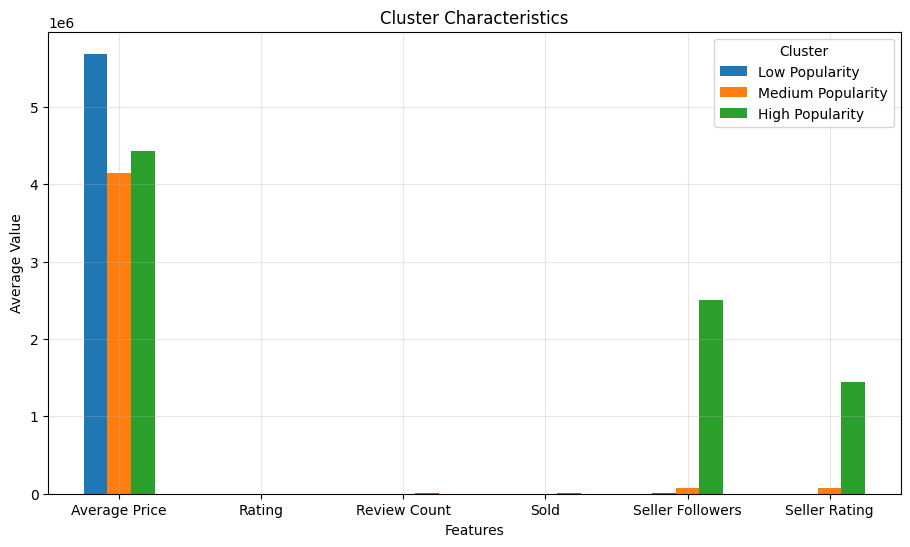

In [96]:
cluster_center_plot = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

cluster_center_plot.columns = [
    "Average Price",
    "Rating",
    "Review Count",
    "Sold",
    "Seller Followers",
    "Seller Rating"
]

cluster_center_plot.index = [
    "Low Popularity",
    "Medium Popularity",
    "High Popularity"
]

cluster_center_plot.T.plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Cluster Characteristics")

plt.xlabel("Features")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.legend(title="Cluster")

plt.grid(alpha=0.3)

plt.show()

## Simpan Dataset

Dataset hasil clustering disimpan untuk digunakan pada tahap analisis selanjutnya.

In [97]:
df.to_csv(
    "../data/processed/ecommerce_cluster.csv",
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.
